#  MuJoCo Bootcamp : Inverse Kinematics

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/qMRUxFexKUc

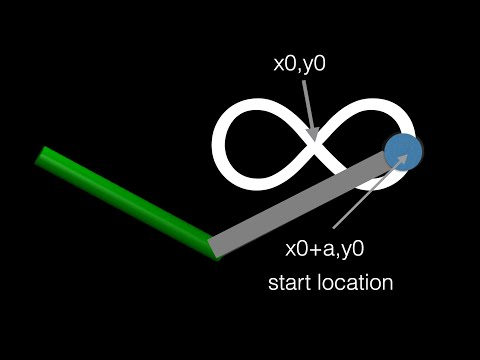

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('qMRUxFexKUc')

## Run python code

In [ ]:
!python manipulator_ik.py

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv
from scipy.linalg import solve_continuous_are
import os
import nlopt
import matplotlib.pyplot as plt

# Create an XML file string for a simple ball on a plane
xml_path = "./manipulator.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)  # MuJoCo model
data = mj.MjData(model)                # MuJoCo data
data_sim = mj.MjData(model)            #data structure for forward/inverse kinematics

### Setup the controller

In [2]:
omega = 0.4
a = 0.25
simend = 0.25 + 2 * np.pi / omega
center_x = None
center_z = None
X_target = None #np.array([0,0]);


def controller(model, data):
    # Get reference end-effector position
    global X_target

    X_target = get_lemniscate_ref(data.time)

    # Use current joint angles as the initial guess
    qpos = np.array([data.qpos[0], data.qpos[1]])

    # Solve for the joint angles
    sol = inverse_kinematics(qpos)

    # Apply control
    data.ctrl[0] = sol[0]
    data.ctrl[2] = sol[1]

def forward_kinematics(self, q):
    data_sim.qpos[0] = q[0]
    data_sim.qpos[1] = q[1]
    data_sim.ctrl[0] = data_sim.qpos[0]
    data_sim.ctrl[2] = data_sim.qpos[1]

    mj.mj_forward(model, data_sim)

    end_eff_pos = np.array([
        data_sim.sensordata[0],
        data_sim.sensordata[2]
    ])

    return end_eff_pos

def init_controller(model, data):
    global center_x
    global center_z
    global X_target

    # Get center of Lemniscate
    end_eff_pos = forward_kinematics([-0.5, 1.0])
    center_x = end_eff_pos[0] - 0.25
    center_z = end_eff_pos[1]

    # Get initial joint angles
    q_guess = np.array([-0.5, 1.0])
    X_target = get_lemniscate_ref(0.0)
    q_pos = inverse_kinematics(q_guess)

    data.qpos[0] = q_pos[0]
    data.qpos[1] = q_pos[1]

def forward_kinematics(q):
    data_sim.qpos[0] = q[0]
    data_sim.qpos[1] = q[1]
    data_sim.ctrl[0] = data_sim.qpos[0]
    data_sim.ctrl[2] = data_sim.qpos[1]

    mj.mj_forward(model, data_sim)

    end_eff_pos = np.array([
        data_sim.sensordata[0],
        data_sim.sensordata[2]
    ])

    return end_eff_pos

def cost_func(x, grad):
    cost = 0.0
    return cost

def equality_constraints(result, x, grad):
    global X_target

    end_eff_pos = forward_kinematics(x)
    result[0] = end_eff_pos[0] - X_target[0]
    result[1] = end_eff_pos[1] - X_target[1]

def inverse_kinematics(x):
    # Define optimization problem
    opt = nlopt.opt(nlopt.LN_COBYLA, 2)

    # Define lower and upper bounds
    opt.set_lower_bounds([-np.pi, -np.pi])
    opt.set_upper_bounds([np.pi, np.pi])

    # Set objective funtion
    opt.set_min_objective(cost_func)

    # Define equality constraints
    tol = [1e-4, 1e-4]
    opt.add_equality_mconstraint(equality_constraints, tol)

    # Set relative tolerance on optimization parameters
    opt.set_xtol_rel(1e-4)

    # Solve problem
    sol = opt.optimize(x)

    return sol

def get_lemniscate_ref(t):
    global center_x
    global center_z
    global omega
    global a

    wt = omega * t
    denominator = 1 + np.sin(wt) * np.sin(wt)

    x = center_x + (a * np.cos(wt)) / denominator
    z = center_z + (a * np.sin(wt) * np.cos(wt)) / denominator

    ref_pos = np.array([x, z])

    return ref_pos

def graph():
    # Measured motion trajectory
    global end_eff_pos
    end_eff_pos_arr = np.concatenate(end_eff_pos, axis=1)

    # Get reference trajectory
    wt = omega * np.linspace(0.0, simend, 500)
    denominator = 1 + np.sin(wt) * np.sin(wt)
    leminiscate_x = center_x + (a * np.cos(wt)) / denominator
    leminiscate_z = center_z + \
        (a * np.sin(wt) * np.cos(wt)) / denominator

    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.plot(
        end_eff_pos_arr[0, :],
        end_eff_pos_arr[1, :],
        color="cornflowerblue",
        linewidth=4,
        zorder=-2,
        label="Inverse Kinematics"
    )
    ax.plot(
        leminiscate_x,
        leminiscate_z,
        color="darkorange",
        linewidth=1,
        zorder=-1,
        label="Reference"
    )

    ax.grid()
    ax.set_aspect("equal")
    ax.legend(frameon=False, ncol=2, loc="lower center",
              bbox_to_anchor=(0.5, -0.4))


    #plt.show()
    plt.show(block=False)
    plt.pause(5)
    plt.close()
    # plt.savefig("imgs/manipulator_ik.png", dpi=200,
    #             transparent=False, bbox_inches="tight")

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [4]:
#initialize the controller
init_controller(model,data)
# Create list to store data
end_eff_pos = []

#set the controller
# mj.set_mjcb_control(controller)



### Simulation

This browser does not support the video tag.


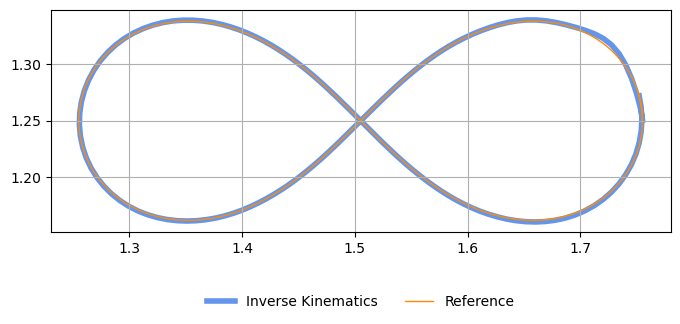

In [5]:
# Store frames for visualization
frames = []
framerate = 60
# simend = 5

# mj.mj_resetData(model, data)
# init_controller(model,data)

while data.time < simend:
    simstart = data.time
    while (data.time - simstart < 0.1): # Use 1/60 = 0.01667 for slower animation
        controller(model, data)
        mj.mj_step(model, data)
    
    end_eff_pos_temp = np.array([
        data.sensordata[0],
        data.sensordata[2]])
    end_eff_pos.append(end_eff_pos_temp[:, np.newaxis])
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)

graph()
